In [3]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
import re
import jieba

In [108]:
movies = {
    '12 Angry Men': [['Sidney Lumet'], ['Henry Fonda', 'Lee J. Cobb', 'Ed Begley']],
    '2001: A Space Odyssey': [['Stanley Kubrick'], ['Keir Dullea', 'Gary Lockwood', 'William Sylvester']],
    'A Beautiful Mind': [['Ron Howard'], ['Russell Crowe', 'Jennifer Connelly', 'Ed Harris']],
    'Avatar': [['James Cameron'], ['Sam Worthington', 'Zoe Saldana', 'Sigourney Weaver']],
    'Black Swan': [['Darren Aronofsky'], ['Natalie Portman', 'Mila Kunis', 'Vincent Cassel']],
    'Bohemian Rhapsody': [['Bryan Singer'], ['Rami Malek', 'Lucy Boynton', 'Gwilym Lee']],
    'Catch Me If You Can': [['Steven Spielberg'], ['Leonardo DiCaprio', 'Tom Hanks', 'Christopher Walken']],
    'Coco': [['Lee Unkrich', 'Adrian Molina'], ['Anthony Gonzalez', 'Gael García Bernal', 'Benjamin Bratt']],
    'Django Unchained': [['Quentin Tarantino'], ['Jamie Foxx', 'Christoph Waltz', 'Leonardo DiCaprio']],
    'Fight Club': [['David Fincher'], ['Brad Pitt', 'Edward Norton', 'Helena Bonham Carter']],
    'Forrest Gump': [['Robert Zemeckis'], ['Tom Hanks', 'Robin Wright', 'Gary Sinise']],
    'Frozen': [['Chris Buck', 'Jennifer Lee'], ['Kristen Bell', 'Idina Menzel', 'Jonathan Groff']],
    'Gone Girl': [['David Fincher'], ['Ben Affleck', 'Rosamund Pike', 'Neil Patrick Harris']],
    'Good Will Hunting': [['Gus Van Sant'], ['Matt Damon', 'Robin Williams', 'Ben Affleck']],
    'Green Book': [['Peter Farrelly'], ['Viggo Mortensen', 'Mahershala Ali', 'Linda Cardellini']],
    'Hacksaw Ridge': [['Mel Gibson'], ['Andrew Garfield', 'Sam Worthington', 'Luke Bracey']],
    "Harry Potter and the Sorcerer's Stone": [['Chris Columbus'], ['Daniel Radcliffe', 'Rupert Grint', 'Emma Watson']],
    'How to Train Your Dragon': [['Dean DeBlois', 'Chris Sanders'], ['Jay Baruchel', 'Gerard Butler', 'Craig Ferguson']],
    'Inception': [['Christopher Nolan'], ['Leonardo DiCaprio', 'Marion Cotillard', 'Tom Hardy']],
    'Inglourious Basterds': [['Quentin Tarantino'], ['Brad Pitt', 'Christoph Waltz', 'Mélanie Laurent']],
    'Inside Out': [['Pete Docter', 'Ronnie Del Carmen'], ['Amy Poehler', 'Phyllis Smith', 'Richard Kind']],
    'Interstellar': [['Christopher Nolan'], ['Matthew McConaughey', 'Anne Hathaway', 'Jessica Chastain']],
    'Joker': [['Todd Phillips'], ['Joaquin Phoenix', 'Robert De Niro', 'Zazie Beetz']],
    'La La Land': [['Damien Chazelle'], ['Ryan Gosling', 'Emma Stone', 'John Legend']],
    'Life Is Beautiful': [['Roberto Benigni'], ['Roberto Benigni', 'Nicoletta Braschi', 'Giorgio Cantarini']],
    'Life of Pi': [['Ang Lee'], ['Suraj Sharma', 'Irrfan Khan', 'Rafe Spall']],
    'Lock, Stock and Two Smoking Barrels': [['Guy Ritchie'], ['Jason Flemyng', 'Dexter Fletcher', 'Nick Moran']],
    'Léon: The Professional': [['Luc Besson'], ['Jean Reno', 'Natalie Portman', 'Gary Oldman']],
    'Mad Max: Fury Road': [['George Miller'], ['Tom Hardy', 'Charlize Theron', 'Nicholas Hoult']],
    'Memento': [['Christopher Nolan'], ['Guy Pearce', 'Carrie-Anne Moss', 'Joe Pantoliano']],
    'Monsters, Inc.': [['Pete Docter', 'David Silverman', 'Lee Unkrich'], ['John Goodman', 'Billy Crystal', 'Mary Gibbs']],
    "One Flew Over the Cuckoo's Nest": [['Miloš Forman'], ['Jack Nicholson', 'Louise Fletcher', 'Danny DeVito']],
    'Parasite': [['Bong Joon-ho'], ['Song Kang-ho', 'Lee Sun-kyun', 'Cho Yeo-jeong']],
    'Pirates of the Caribbean: The Curse of the Black Pearl': [['Gore Verbinski'], ['Johnny Depp', 'Geoffrey Rush', 'Orlando Bloom']],
    'Psycho': [['Alfred Hitchcock'], ['Anthony Perkins', 'Janet Leigh', 'Vera Miles']],
    'Pulp Fiction': [['Quentin Tarantino'], ['John Travolta', 'Samuel L. Jackson', 'Uma Thurman']],
    'Saving Private Ryan': [['Steven Spielberg'], ['Tom Hanks', 'Matt Damon', 'Tom Sizemore']],
    "Schindler's List": [['Steven Spielberg'], ['Liam Neeson', 'Ben Kingsley', 'Ralph Fiennes']],
    'Se7en': [['David Fincher'], ['Morgan Freeman', 'Brad Pitt', 'Gwyneth Paltrow']],
    'Shutter Island': [['Martin Scorsese'], ['Leonardo DiCaprio', 'Mark Ruffalo', 'Ben Kingsley']],
    'Slumdog Millionaire': [['Danny Boyle', 'Loveleen Tandan'], ['Dev Patel', 'Freida Pinto', 'Madhur Mittal']],
    'Spider-Man: Into the Spider-Verse': [['Bob Persichetti', 'Peter Ramsey', 'Rodney Rothman'], ['Shameik Moore', 'Jake Johnson', 'Hailee Steinfeld']],
    'Spirited Away': [['Hayao Miyazaki'], ['Rumi Hiiragi', 'Miyu Irino', 'Mari Natsuki']],
    'Terminator 2: Judgment Day': [['James Cameron'], ['Arnold Schwarzenegger', 'Linda Hamilton', 'Edward Furlong']],
    'The Bourne Ultimatum': [['Paul Greengrass'], ['Matt Damon', 'Julia Stiles', 'David Strathairn']],
    'The Curious Case of Benjamin Button': [['David Fincher'], ['Brad Pitt', 'Cate Blanchett', 'Taraji P. Henson']],
    'The Dark Knight': [['Christopher Nolan'], ['Christian Bale', 'Heath Ledger', 'Aaron Eckhart']],
    'The Godfather': [['Francis Ford Coppola'], ['Marlon Brando', 'Al Pacino', 'James Caan']],
    'The Grand Budapest Hotel': [['Wes Anderson'], ['Ralph Fiennes', 'F. Murray Abraham', 'Mathieu Amalric']],
    'The Green Mile': [['Frank Darabont'], ['Tom Hanks', 'Michael Clarke Duncan', 'David Morse']],
    'The Imitation Game': [['Morten Tyldum'], ['Benedict Cumberbatch', 'Keira Knightley', 'Matthew Goode']],
    'The Intouchables': [['Olivier Nakache', 'Éric Toledano'], ['François Cluzet', 'Omar Sy', 'Anne Le Ny']],
    'The Lion King': [['Roger Allers', 'Rob Minkoff'], ['Matthew Broderick', 'Jeremy Irons', 'James Earl Jones']],
    'The Lord of the Rings: The Return of the King': [['Peter Jackson'], ['Elijah Wood', 'Ian McKellen', 'Viggo Mortensen']],
    'The Martian': [['Ridley Scott'], ['Matt Damon', 'Jessica Chastain', 'Kristen Wiig']],
    'The Matrix': [['Lana Wachowski', 'Lilly Wachowski'], ['Keanu Reeves', 'Laurence Fishburne', 'Carrie-Anne Moss']],
    'The Notebook': [['Nick Cassavetes'], ['Ryan Gosling', 'Rachel McAdams', 'James Garner']],
    'The Pianist': [['Roman Polanski'], ['Adrien Brody', 'Thomas Kretschmann', 'Frank Finlay']],
    'The Prestige': [['Christopher Nolan'], ['Hugh Jackman', 'Christian Bale', 'Michael Caine']],
    'The Shawshank Redemption': [['Frank Darabont'], ['Tim Robbins', 'Morgan Freeman', 'Bob Gunton']],
    'The Silence of the Lambs': [['Jonathan Demme'], ['Jodie Foster', 'Anthony Hopkins', 'Scott Glenn']],
    'The Sixth Sense': [['M. Night Shyamalan'], ['Bruce Willis', 'Haley Joel Osment', 'Toni Collette']],
    'The Truman Show': [['Peter Weir'], ['Jim Carrey', 'Laura Linney', 'Noah Emmerich']],
    'Titanic': [['James Cameron'], ['Leonardo DiCaprio', 'Kate Winslet', 'Billy Zane']],
    'Toy Story 3': [['Lee Unkrich'], ['Tom Hanks', 'Tim Allen', 'Joan Cusack']],
    'Up': [['Pete Docter', 'Bob Peterson'], ['Ed Asner', 'Christopher Plummer', 'Jordan Nagai']],
    'WALL·E': [['Andrew Stanton'], ['Ben Burtt', 'Elissa Knight', 'Jeff Garlin']],
    'Whiplash': [['Damien Chazelle'], ['Miles Teller', 'J.K. Simmons', 'Paul Reiser']]
}

In [4]:
# Load CSVs
df_en = pd.read_csv('../imdb_reviews.csv')

# Download English stopwords if needed
nltk.download('stopwords')
eng_stopwords = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/elimarx/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [5]:
df_en

,title,comment,rating
0,Se7en,"So when this movie came out, it was pretty gor...",1
1,Se7en,Horrible movie. Incredibly boring and predicta...,1
2,Se7en,What a boring movie. Idk what the stupid hype ...,1
3,Se7en,"Well Kevin ruined the movie, obviously. I'd lo...",1
4,Se7en,Watched this because it was suggested in a rev...,1
...,...,...,...
7702,Django Unchained,Just for a moment imagine this movie being mad...,4
7703,Django Unchained,Last week I managed to watch Django Unchained ...,4
7704,Django Unchained,Another disappointment from Tarantino. A juven...,4
7705,Django Unchained,One thing that you can always guarantee with a...,4


In [110]:
#function of all of this is to get rid self mentions of titles, actors, and director
import re
import nltk
from nltk.corpus import stopwords
from fuzzywuzzy import fuzz
import string

nltk.download('stopwords', quiet=True)

SPECIAL_TOKENS = {"<MOVIE_TITLE>", "<DIRECTOR_NAME>", "<ACTOR_NAME>"}

def normalize_for_matching(text):
    """Normalize text for matching purposes only."""
    return re.sub(r"[^\w\s]", "", text.lower())

def find_title_mentions(text, title):
    """
    Find all exact, case-insensitive, whole-word matches of the movie title.
    Returns a list of (start, end, tag) tuples.
    """
    matches = []
    if not title or len(title) < 2:
        return matches
    
    # Create pattern that handles word boundaries properly
    pattern = r'\b' + re.escape(title) + r'\b'
    
    for m in re.finditer(pattern, text, flags=re.IGNORECASE):
        matches.append((m.start(), m.end(), "<MOVIE_TITLE>"))
    
    return matches

def find_name_mentions(text, names, min_ratio=85):
    """
    Find matches for director/actor names in text with improved accuracy.
    """
    matches = []
    
    for name, tag in names:
        if not name or len(name.split()) < 2:
            continue
            
        # Try exact match first (case-insensitive)
        pattern = r'\b' + re.escape(name) + r'\b'
        for m in re.finditer(pattern, text, flags=re.IGNORECASE):
            matches.append((m.start(), m.end(), tag))
        
        # Try possessive form (e.g., "Nolan's" for "Christopher Nolan")
        last_name = name.split()[-1]
        if len(last_name) > 2:  # Avoid matching very short names
            possessive_pattern = r'\b' + re.escape(last_name) + r"'s?\b"
            for m in re.finditer(possessive_pattern, text, flags=re.IGNORECASE):
                # Verify this isn't part of a common word
                match_text = text[m.start():m.end()].lower()
                if not is_common_word_with_s(match_text.rstrip("'s")):
                    matches.append((m.start(), m.end(), tag))
        
        # Try partial name matching with stricter criteria
        name_parts = name.lower().split()
        if len(name_parts) >= 2:
            # Look for first + last name
            first_last_pattern = r'\b' + re.escape(name_parts[0]) + r'\s+' + re.escape(name_parts[-1]) + r'\b'
            for m in re.finditer(first_last_pattern, text, flags=re.IGNORECASE):
                matches.append((m.start(), m.end(), tag))
            
            # Look for just last name if it's distinctive enough
            if len(name_parts[-1]) >= 4 and name_parts[-1] not in get_common_words():
                last_name_pattern = r'\b' + re.escape(name_parts[-1]) + r'\b'
                for m in re.finditer(last_name_pattern, text, flags=re.IGNORECASE):
                    # Check context to avoid false positives
                    if is_likely_name_reference(text, m.start(), m.end()):
                        matches.append((m.start(), m.end(), tag))
    
    return matches

def is_common_word_with_s(word):
    """Check if a word is a common English word that might end with 's."""
    common_words = {
        'his', 'hers', 'its', 'theirs', 'ours', 'yours', 'this', 'that',
        'was', 'has', 'does', 'goes', 'comes', 'makes', 'takes', 'gives',
        'seems', 'looks', 'feels', 'sounds', 'appears', 'becomes'
    }
    return word.lower() in common_words

def get_common_words():
    """Get a set of common English words to avoid matching."""
    return {
        'the', 'be', 'to', 'of', 'and', 'a', 'in', 'that', 'have', 'it',
        'for', 'not', 'on', 'with', 'he', 'as', 'you', 'do', 'at', 'this',
        'but', 'his', 'by', 'from', 'they', 'we', 'say', 'her', 'she', 'or',
        'an', 'will', 'my', 'one', 'all', 'would', 'there', 'their', 'what',
        'so', 'up', 'out', 'if', 'about', 'who', 'get', 'which', 'go', 'me',
        'when', 'make', 'can', 'like', 'time', 'no', 'just', 'him', 'know',
        'take', 'people', 'into', 'year', 'your', 'good', 'some', 'could',
        'them', 'see', 'other', 'than', 'then', 'now', 'look', 'only', 'come',
        'its', 'over', 'think', 'also', 'back', 'after', 'use', 'two', 'how',
        'our', 'work', 'first', 'well', 'way', 'even', 'new', 'want', 'because',
        'any', 'these', 'give', 'day', 'most', 'us', 'still', 'find', 'tell',
        'really', 'dark', 'great', 'movie', 'film', 'scene', 'character', 'story',
        'plot', 'director', 'actor', 'actress', 'hero', 'villain', 'killer',
        'murder', 'death', 'child', 'mind', 'moral', 'figure', 'foundation'
    }

def is_likely_name_reference(text, start, end):
    """Check if a match is likely to be a name reference based on context."""
    # Look at surrounding context
    context_start = max(0, start - 20)
    context_end = min(len(text), end + 20)
    context = text[context_start:context_end].lower()
    
    # Positive indicators
    name_indicators = ['directed by', 'starring', 'actor', 'actress', 'star', 
                      'performance', 'played by', 'cast', 'role']
    
    # Negative indicators (words that suggest it's not a name)
    not_name_indicators = ['the', 'a', 'an', 'is', 'was', 'were', 'are',
                           'his', 'her', 'its', 'their', 'this', 'that']
    
    # Check for positive indicators
    for indicator in name_indicators:
        if indicator in context:
            return True
    
    # Check if the word immediately before is a negative indicator
    word_before = text[max(0, start-10):start].strip().split()[-1:] if start > 0 else []
    if word_before and word_before[0].lower() in not_name_indicators:
        return False
    
    return True

def remove_overlapping(matches):
    """Remove overlapping matches, keeping the longest ones."""
    if not matches:
        return []
    
    # Sort by start position, then by length (longest first)
    matches = sorted(matches, key=lambda x: (x[0], -(x[1]-x[0])))
    
    result = []
    last_end = -1
    
    for start, end, tag in matches:
        if start >= last_end:
            result.append((start, end, tag))
            last_end = end
    
    return result

def preprocess_movie_review(text, movies, title):
    """
    Preprocess a movie review with improved entity recognition.
    """
    if title not in movies:
        # Just do basic preprocessing if movie not in dictionary
        text_lower = text.lower()
        text_no_punct = re.sub(r"[^\w\s]", "", text_lower)
        words = text_no_punct.split()
        stops = set(stopwords.words("english"))
        cleaned = [w for w in words if w not in stops]
        return " ".join(cleaned)
    
    directors, actors = movies[title]
    
    # Find all entity matches
    entity_matches = []
    
    # Find title mentions
    entity_matches.extend(find_title_mentions(text, title))
    
    # Find director and actor mentions
    entity_matches.extend(find_name_mentions(text, [(d, "<DIRECTOR_NAME>") for d in directors]))
    entity_matches.extend(find_name_mentions(text, [(a, "<ACTOR_NAME>") for a in actors]))
    
    # Remove overlapping matches
    entity_matches = remove_overlapping(entity_matches)
    
    # Replace entities in text (from end to start to preserve indices)
    new_text = text
    for start, end, tag in sorted(entity_matches, key=lambda x: -x[0]):
        new_text = new_text[:start] + tag + new_text[end:]
    
    # Lowercase and remove punctuation
    new_text = new_text.lower()
    
    # Preserve special tokens while removing punctuation
    for token in SPECIAL_TOKENS:
        new_text = new_text.replace(token.lower(), f" {token} ")
    
    # Remove punctuation except for angle brackets
    new_text = re.sub(r"[^\w\s<>]", " ", new_text)
    
    # Tokenize
    words = new_text.split()
    
    # Remove stopwords except special tokens
    stops = set(stopwords.words("english"))
    cleaned = [w for w in words if w in SPECIAL_TOKENS or w not in stops]
    
    return " ".join(cleaned)

In [111]:
df_en['processed_comment'] = df_en.apply(
    lambda row: preprocess_movie_review(row['comment'], movies, row['title']),
    axis=1
)

In [113]:
#load in custom stopwords
custom_stopwords = set(open('../text_processing/custom_english_stopwords.txt', encoding='utf-8').read().split())
words = []
for word in custom_stopwords:
    word = word.lower()
    words.append(word)
custom_stopwords = set(words)

In [114]:
# English preprocessing
def clean_english(text):
    text = str(text).lower()
    words = [w for w in text.split() if w not in custom_stopwords]
    return ' '.join(words)

# Apply preprocessing
df_en['clean_comment'] = df_en['processed_comment'].apply(clean_english)

In [117]:
df_en.loc[1]['clean_comment']

'horrible incredibly boring predictable longing would end bad captivating played exactly even little figured play would rather watched sausage party bad still unpredictable surprising thing makes upset even bad plot much potential concept could still ended bad boring understand 2 hours still feel shallow undetailed please waste bad'

In [97]:
comments = df_en["clean_comment"].dropna().tolist()

In [98]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-mpnet-base-v2")

embeddings = model.encode(comments, show_progress_bar=True)

Batches: 100%|██████████| 241/241 [01:38<00:00,  2.45it/s]


In [99]:
#do clustering
from sklearn.cluster import KMeans

num_clusters = 6 # tweak this
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
labels = kmeans.fit_predict(embeddings)

df_en['cluster'] = labels

In [100]:
df_en['cluster'].value_counts()

cluster
5    1886
4    1678
1    1492
0    1225
3     998
2     428
Name: count, dtype: int64

In [101]:
#analysis tools
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from keybert import KeyBERT
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

def extract_keybert_keywords(df_en, model, num_keywords=10):
    print("=== KEYBERT KEYWORDS ===\n")
    kw_model = KeyBERT(model)
    for i in range(num_clusters):
        cluster_comments = df_en[df_en['cluster'] == i]['clean_comment'].tolist()
        joined = " ".join(cluster_comments)
        keywords = kw_model.extract_keywords(joined, top_n=num_keywords)
        print(f"Cluster {i} keywords:", keywords)
    
    print()

def analyze_clusters_comprehensive(df_en, text_column='processed_comment'):
    """
    Comprehensive cluster analysis with multiple methods
    """
    
    # 1. TF-IDF Based Analysis (most discriminative terms per cluster)
    print("=== TF-IDF DISCRIMINATIVE TERMS ===\n")
    
    # Create a document for each cluster by joining all comments
    cluster_docs = []
    for i in range(df_en['cluster'].nunique()):
        cluster_text = ' '.join(df_en[df_en['cluster'] == i][text_column].tolist())
        cluster_docs.append(cluster_text)
    
    # Compute TF-IDF
    tfidf = TfidfVectorizer(max_features=100, ngram_range=(1, 3), stop_words='english')
    tfidf_matrix = tfidf.fit_transform(cluster_docs)
    feature_names = tfidf.get_feature_names_out()
    
    # Get top terms for each cluster based on TF-IDF scores
    for i in range(len(cluster_docs)):
        scores = tfidf_matrix[i].toarray().flatten()
        top_indices = scores.argsort()[-15:][::-1]  # Top 15 terms
        top_terms = [(feature_names[idx], scores[idx]) for idx in top_indices]
        
        print(f"Cluster {i} - Most Discriminative Terms:")
        for term, score in top_terms[:10]:
            print(f"  {term}: {score:.3f}")
        print()
    
    # 3. Movie and Rating Distribution
    print("\n=== MOVIE & RATING DISTRIBUTION ===\n")
    
    for i in range(df_en['cluster'].nunique()):
        cluster_df = df_en[df_en['cluster'] == i]
        
        print(f"Cluster {i}:")
        print(f"  Size: {len(cluster_df)} reviews")
        
        # Top movies in this cluster
        top_movies = cluster_df['title'].value_counts().head(5)
        print(f"  Top movies:")
        for movie, count in top_movies.items():
            print(f"    - {movie}: {count} reviews")
        
        # Rating distribution if available
        if 'rating' in df_en.columns:
            print(f"  Average rating: {cluster_df['rating'].mean():.2f}")
            print(f"  Rating std: {cluster_df['rating'].std():.2f}")
        
        print()

    # 5. Length Analysis
    print("\n=== REVIEW LENGTH ANALYSIS ===\n")
    
    df_en['review_length'] = df_en[text_column].str.split().str.len()
    
    for i in range(df_en['cluster'].nunique()):
        cluster_lengths = df_en[df_en['cluster'] == i]['review_length']
        print(f"Cluster {i}:")
        print(f"  Average length: {cluster_lengths.mean():.1f} words")
        print(f"  Median length: {cluster_lengths.median():.1f} words")
        print()
    
    # 4. Special Token Analysis
    print("\n=== SPECIAL TOKEN USAGE ===\n")
    
    special_tokens = [ 'director_name', 'actor_name']
    
    for i in range(df_en['cluster'].nunique()):
        cluster_comments = df_en[df_en['cluster'] == i][text_column].tolist()
        all_text = ' '.join(cluster_comments)
        
        print(f"Cluster {i}:")
        for token in special_tokens:
            count = all_text.count(token)
            avg_per_review = count / len(cluster_comments)
            print(f"  {token}: {count} total ({avg_per_review:.2f} per review)")
        print()

def get_sample_reviews(df_en, n_samples=3):
#print some random comments from each cluster
    """
    Get representative reviews from each cluster
    """
    print("\n=== RANDOM SAMPLE REVIEWS ===\n")
    
    for cluster_num in sorted(df_en['cluster'].unique()):
        print(f"\nCluster {cluster_num}:")
        sample_comments = df_en[df_en['cluster'] == cluster_num]['comment'].sample(n_samples, random_state=42)
        for comment in sample_comments:
            print(" -", comment)
            print()
        print("-" * 40)

def extract_unique_ngrams(df_en, text_column='processed_comment'):
    """
    Find n-grams that are unique or highly specific to each cluster
    """
    print("\n=== UNIQUE N-GRAMS PER CLUSTER ===\n")
    
    from sklearn.feature_extraction.text import CountVectorizer
    
    # Get n-grams for each cluster
    cluster_ngrams = {}
    
    for i in range(df_en['cluster'].nunique()):
        cluster_text = df_en[df_en['cluster'] == i][text_column].tolist()
        
        # Extract bigrams and trigrams
        vectorizer = CountVectorizer(ngram_range=(2, 3), max_features=100)
        try:
            ngram_counts = vectorizer.fit_transform(cluster_text)
            feature_names = vectorizer.get_feature_names_out()
            
            # Sum occurrences across all documents in cluster
            total_counts = ngram_counts.sum(axis=0).A1
            ngram_freq = list(zip(feature_names, total_counts))
            ngram_freq.sort(key=lambda x: x[1], reverse=True)
            
            cluster_ngrams[i] = dict(ngram_freq[:20])  # Top 20 n-grams
        except:
            cluster_ngrams[i] = {}
    
    # Find n-grams unique to each cluster
    for i in range(df_en['cluster'].nunique()):
        print(f"Cluster {i} - Unique/Distinctive N-grams:")
        
        current_ngrams = set(cluster_ngrams[i].keys())
        other_ngrams = set()
        
        for j in range(df_en['cluster'].nunique()):
            if j != i:
                other_ngrams.update(cluster_ngrams[j].keys())
        
        unique_ngrams = current_ngrams - other_ngrams
        
        if unique_ngrams:
            for ngram in list(unique_ngrams)[:10]:
                print(f"  - {ngram}: {cluster_ngrams[i][ngram]} occurrences")
        else:
            # If no unique n-grams, show most frequent
            for ngram, count in list(cluster_ngrams[i].items())[:5]:
                print(f"  - {ngram}: {count} occurrences")
        print()

def visualize_clusters(df_en, embeddings):
    """
    Visualize clusters using dimensionality reduction
    """
    # PCA visualization
    pca = PCA(n_components=2)
    pca_coords = pca.fit_transform(embeddings)
    
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    scatter = plt.scatter(pca_coords[:, 0], pca_coords[:, 1], 
                         c=df_en['cluster'], cmap='tab10', alpha=0.6)
    plt.colorbar(scatter)
    plt.title('Clusters in PCA Space')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    
    # t-SNE visualization (for smaller datasets)
    if len(df_en) < 5000:  # t-SNE is computationally expensive
        tsne = TSNE(n_components=2, random_state=42)
        tsne_coords = tsne.fit_transform(embeddings)
        
        plt.subplot(1, 2, 2)
        scatter = plt.scatter(tsne_coords[:, 0], tsne_coords[:, 1], 
                             c=df_en['cluster'], cmap='tab10', alpha=0.6)
        plt.colorbar(scatter)
        plt.title('Clusters in t-SNE Space')
        plt.xlabel('t-SNE 1')
        plt.ylabel('t-SNE 2')
    
    plt.tight_layout()
    plt.show()

def visualize_clusters2(df_en, embeddings):
    """
    Visualize clusters using dimensionality reduction but different output
    """
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(embeddings)

    df_en['x'] = reduced[:, 0]
    df_en['y'] = reduced[:, 1]

    plt.figure(figsize=(10, 7))
    sns.scatterplot(data=df_en, x='x', y='y', hue='cluster', palette='tab10')
    plt.title("IMDB Comment Clusters")
    plt.show()

def analyze_cluster_themes(df_en, text_column='processed_comment'):
    """
    High-level theme analysis based on semantic patterns
    """
    print("\n=== POTENTIAL CLUSTER THEMES ===\n")
    
     # Define theme indicators
    theme_patterns = {
        'Technical/Cinematography': [
            # English terms
            'cinematography', 'camera', 'shot', 'visual', 'effects', 'lighting', 'score', 'soundtrack',
            'editing', 'montage', 'framing', 'composition', 'color grading', 'special effects', 'vfx',
            'sound design', 'audio', 'music', 'film grain', 'aspect ratio', 'lens', 'focus',
            'depth of field', 'bokeh', 'exposure', 'contrast', 'saturation',
            # Chinese terms
            '摄影', '镜头', '视觉', '特效', '灯光', '配乐', '音响', '剪辑', '蒙太奇',
            '构图', '调色', '音效设计', '音乐', '画面', '色彩', '光影', '景深', '对焦',
            '曝光', '对比度', '饱和度', '画质', '视效'
        ],
        
        'Plot/Story': [
            # English terms
            'plot', 'story', 'narrative', 'ending', 'twist', 'predictable', 'boring', 'confusing',
            'storyline', 'script', 'screenplay', 'dialogue', 'pacing', 'structure', 'climax',
            'resolution', 'character development', 'arc', 'subplot', 'foreshadowing', 'flashback',
            'theme', 'message', 'moral', 'symbolism', 'metaphor', 'allegory',
            # Chinese terms
            '剧情', '故事', '叙事', '结局', '转折', '反转', '可预测', '无聊', '混乱',
            '故事线', '剧本', '对话', '节奏', '结构', '高潮', '解决', '人物发展',
            '情节', '伏笔', '闪回', '主题', '寓意', '象征', '隐喻', '寓言'
        ],
        
        'Acting/Performance': [
            # English terms
            '<ACTOR_NAME>', 'actor_name', 'acting', 'performance', 'character', 'role', 'cast',
            '演员', 'protagonist', 'antagonist', 'supporting actor', 'lead role', 'ensemble',
            'chemistry', 'charisma', 'believable', 'convincing', 'overacting', 'underacting',
            'method acting', 'improvisation', 'delivery', 'emotion', 'expression',
            # Chinese terms
            '演员', '表演', '角色', '演技', '主角', '配角', '反派', '演出', '情感',
            '表情', '台词功底', '化学反应', '魅力', '可信度', '过度表演', '表演不足',
            '即兴发挥', '情绪', '演绎'
        ],
        
        'Direction': [
            # English terms
            '<DIRECTOR_NAME>', 'director_name', 'direction', 'directed', 'filmmaker',
            'directing', 'vision', 'style', 'auteur', 'mise-en-scène', 'directorial',
            'execution', 'craft', 'artistic vision', 'creative control', 'helm',
            # Chinese terms
            '导演', '执导', '导演风格', '艺术视野', '执行', '创作', '掌控', '导演手法',
            '艺术家', '创意', '视觉风格'
        ],
        
        'Genre-specific': [
            # English terms
            'horror', 'comedy', 'thriller', 'drama', 'action', 'romantic', 'sci-fi', 'fantasy',
            'western', 'noir', 'documentary', 'biography', 'historical', 'war', 'crime',
            'mystery', 'adventure', 'animation', 'musical', 'family', 'indie', 'arthouse',
            # Chinese terms
            '恐怖', '喜剧', '惊悚', '剧情', '动作', '浪漫', '爱情', '科幻', '奇幻',
            '西部', '黑色电影', '纪录片', '传记', '历史', '战争', '犯罪', '悬疑',
            '冒险', '动画', '音乐剧', '家庭', '独立电影', '艺术片'
        ],
        
        'Emotional Response': [
            # English terms
            'love', 'hate', 'disappoint', 'amazing', 'terrible', 'worst', 'best', 'masterpiece',
            'brilliant', 'awful', 'stunning', 'boring', 'exciting', 'thrilling', 'moving',
            'touching', 'hilarious', 'frightening', 'beautiful', 'ugly', 'perfect', 'flawed',
            'memorable', 'forgettable', 'impressive', 'disappointing', 'satisfying',
            # Chinese terms
            '喜爱', '讨厌', '失望', '惊艳', '糟糕', '最差', '最好', '杰作', '经典',
            '精彩', '可怕', '惊人', '无聊', '激动', '刺激', '感动', '触动', '搞笑',
            '恐怖', '美丽', '丑陋', '完美', '有缺陷', '难忘', '遗忘', '印象深刻',
            '令人失望', '满意', '震撼'
        ],
        
        'Critical/Analytical': [
            # English terms
            'overrated', 'underrated', 'critic', 'review', 'analysis', 'interpret',
            'evaluation', 'assessment', 'critique', 'rating', 'score', 'recommendation',
            'comparison', 'influence', 'impact', 'legacy', 'cultural significance',
            'artistic merit', 'commercial success', 'box office', 'awards', 'nominations',
            # Chinese terms
            '被高估', '被低估', '评论家', '评论', '分析', '解读', '评估', '评价',
            '批评', '评分', '推荐', '比较', '影响', '冲击', '遗产', '文化意义',
            '艺术价值', '商业成功', '票房', '奖项', '提名'
        ],
        
        'Political/Ideological Sentiment': [
            # English terms
            'propaganda', 'bias', 'political', 'ideology', 'conservative', 'liberal',
            'progressive', 'reactionary', 'nationalist', 'patriotic', 'anti-war', 'pro-war',
            'feminist', 'sexist', 'racist', 'diversity', 'representation', 'inclusive',
            'exclusive', 'mainstream', 'alternative', 'subversive', 'establishment',
            'counter-culture', 'social commentary', 'political correctness', 'woke',
            'traditional values', 'modern values', 'censorship', 'freedom of expression',
            # Chinese terms
            '宣传', '偏见', '政治', '意识形态', '保守', '自由主义', '进步', '反动',
            '民族主义', '爱国', '反战', '支持战争', '女权主义', '性别歧视', '种族主义',
            '多样性', '代表性', '包容', '排斥', '主流', '另类', '颠覆', '建制',
            '反文化', '社会评论', '政治正确', '传统价值', '现代价值', '审查', '表达自由'
        ],
        
        'Cultural/Social Commentary': [
            # English terms
            'cultural', 'society', 'social issues', 'class', 'inequality', 'poverty', 'wealth',
            'religion', 'spirituality', 'atheism', 'morality', 'ethics', 'justice',
            'oppression', 'liberation', 'identity', 'sexuality', 'gender', 'race',
            'ethnicity', 'immigration', 'globalization', 'capitalism', 'socialism',
            # Chinese terms
            '文化', '社会', '社会问题', '阶级', '不平等', '贫困', '财富', '宗教',
            '精神', '无神论', '道德', '伦理', '正义', '压迫', '解放', '身份',
            '性取向', '性别', '种族', '民族', '移民', '全球化', '资本主义', '社会主义'
        ],
        
        'Production/Industry': [
            # English terms
            'budget', 'production', 'studio', 'independent', 'hollywood', 'international',
            'blockbuster', 'franchise', 'sequel', 'prequel', 'remake', 'reboot',
            'adaptation', 'original', 'distribution', 'marketing', 'promotion',
            'release', 'premiere', 'festival', 'awards season', 'oscar bait',
            # Chinese terms
            '预算', '制作', '工作室', '独立', '好莱坞', '国际', '大片', '系列',
            '续集', '前传', '重拍', '重启', '改编', '原创', '发行', '营销',
            '宣传', '发布', '首映', '电影节', '颁奖季', '冲奥'
        ],
        
        'Audience/Reception': [
            # English terms
            'audience', 'viewers', 'fans', 'general public', 'target demographic',
            'accessibility', 'entertainment value', 'rewatchability', 'cult following',
            'mainstream appeal', 'niche', 'polarizing', 'consensus', 'word of mouth',
            'viral', 'trending', 'popular', 'unpopular', 'commercial',
            # Chinese terms
            '观众', '粉丝', '大众', '目标人群', '可及性', '娱乐价值', '重看性',
            '邪典', '主流吸引力', '小众', '两极分化', '共识', '口碑', '病毒式',
            '趋势', '流行', '不受欢迎', '商业'
        ],
        
        'Time/Historical Context': [
            # English terms
            'timeless', 'dated', 'contemporary', 'period piece', 'historical accuracy',
            'anachronism', 'nostalgia', 'retro', 'modern', 'futuristic', 'classic',
            'vintage', 'current', 'relevant', 'irrelevant', 'ahead of its time',
            'behind the times', 'generational', 'timely', 'untimely',
            # Chinese terms
            '永恒', '过时', '当代', '古装', '历史准确性', '时代错误', '怀旧',
            '复古', '现代', '未来', '经典', '老式', '当前', '相关', '无关',
            '超前', '落后', '世代', '及时', '不合时宜'
        ]
    }
    
    for i in range(df_en['cluster'].nunique()):
        cluster_text = ' '.join(df_en[df_en['cluster'] == i][text_column].tolist()).lower()
        
        print(f"\nCluster {i} - Theme Scores:")
        theme_scores = {}
        
        for theme, keywords in theme_patterns.items():
            score = sum(cluster_text.count(keyword.lower()) for keyword in keywords)
            theme_scores[theme] = score
        
        # Normalize by cluster size
        cluster_size = len(df_en[df_en['cluster'] == i])
        
        # Sort themes by score
        sorted_themes = sorted(theme_scores.items(), key=lambda x: x[1], reverse=True)
        
        for theme, score in sorted_themes[:12]:
            normalized_score = score / cluster_size
            print(f"  {theme}: {normalized_score:.2f} mentions per review")
    
    print()


In [102]:
#more keyword extraction tools
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import jieba
import jieba.analyse
from transformers import AutoTokenizer, AutoModel
import torch

class ChineseKeywordExtractor:
    def __init__(self, embedding_model=None):
        self.embedding_model = embedding_model
        # Initialize jieba for Chinese text processing
        jieba.initialize()
        
    def extract_tfidf_keywords(self, df, num_clusters, num_keywords=10, min_df=3, max_df=0.7):
        """
        Extract keywords using TF-IDF with frequency filtering
        """
        print("=== TF-IDF KEYWORDS ===\n")
        
        cluster_texts = []
        for i in range(num_clusters):
            cluster_comments = df[df['cluster'] == i]['clean_comment'].tolist()
            joined = " ".join(cluster_comments)
            cluster_texts.append(joined)
        
        # Use TF-IDF with frequency constraints
        vectorizer = TfidfVectorizer(
            min_df=min_df,  # Term must appear in at least 3 documents
            max_df=max_df,  # Term can't appear in more than 70% of documents
            ngram_range=(1, 2),  # Include both unigrams and bigrams
            stop_words=None  # Handle Chinese stopwords separately if needed
        )
        
        tfidf_matrix = vectorizer.fit_transform(cluster_texts)
        feature_names = vectorizer.get_feature_names_out()
        
        for i in range(num_clusters):
            # Get TF-IDF scores for this cluster
            cluster_scores = tfidf_matrix[i].toarray()[0]
            # Get top keywords
            top_indices = cluster_scores.argsort()[-num_keywords:][::-1]
            keywords = [(feature_names[idx], cluster_scores[idx]) for idx in top_indices]
            print(f"Cluster {i} keywords:", keywords)
    
    def extract_frequency_based_keywords(self, df, num_clusters, num_keywords=10, min_freq=5):
        """
        Extract keywords based on term frequency within clusters vs overall corpus
        """
        print("=== FREQUENCY-BASED KEYWORDS ===\n")
        
        # Get overall term frequencies
        all_text = " ".join(df['clean_comment'].tolist())
        all_words = jieba.lcut(all_text)
        overall_freq = Counter(all_words)
        total_words = len(all_words)
        
        for i in range(num_clusters):
            cluster_comments = df[df['cluster'] == i]['clean_comment'].tolist()
            cluster_text = " ".join(cluster_comments)
            cluster_words = jieba.lcut(cluster_text)
            cluster_freq = Counter(cluster_words)
            cluster_total = len(cluster_words)
            
            # Calculate relative frequency score
            keyword_scores = {}
            for word, freq in cluster_freq.items():
                if freq >= min_freq and len(word) > 1:  # Filter short and rare words
                    cluster_ratio = freq / cluster_total
                    overall_ratio = overall_freq[word] / total_words
                    # Score is how much more frequent the word is in this cluster
                    if overall_ratio > 0:
                        score = cluster_ratio / overall_ratio
                        keyword_scores[word] = score
            
            # Get top keywords
            top_keywords = sorted(keyword_scores.items(), key=lambda x: x[1], reverse=True)[:num_keywords]
            print(f"Cluster {i} keywords:", top_keywords)
    
    def extract_jieba_keywords(self, df, num_clusters, num_keywords=10):
        """
        Use jieba's built-in keyword extraction
        """
        print("=== JIEBA KEYWORDS ===\n")
        
        for i in range(num_clusters):
            cluster_comments = df[df['cluster'] == i]['clean_comment'].tolist()
            joined = " ".join(cluster_comments)
            
            # Use jieba's TextRank algorithm
            keywords_textrank = jieba.analyse.textrank(joined, topK=num_keywords, withWeight=True)
            print(f"Cluster {i} TextRank keywords:", keywords_textrank)
            
            # Use jieba's TF-IDF
            keywords_tfidf = jieba.analyse.extract_tags(joined, topK=num_keywords, withWeight=True)
            print(f"Cluster {i} TF-IDF keywords:", keywords_tfidf)
            print()
    
    def extract_comparative_keywords(self, df, num_clusters, num_keywords=10, contrast_threshold=2.0):
        """
        Extract keywords that are distinctively frequent in each cluster compared to others
        """
        print("=== COMPARATIVE KEYWORDS ===\n")
        
        # Prepare cluster texts and word frequencies
        cluster_word_freq = {}
        total_word_freq = Counter()
        
        for i in range(num_clusters):
            cluster_comments = df[df['cluster'] == i]['clean_comment'].tolist()
            cluster_text = " ".join(cluster_comments)
            words = jieba.lcut(cluster_text)
            cluster_word_freq[i] = Counter(words)
            total_word_freq.update(words)
        
        # For each cluster, find distinctive words
        for cluster_id in range(num_clusters):
            distinctive_scores = {}
            cluster_freq = cluster_word_freq[cluster_id]
            cluster_size = sum(cluster_freq.values())
            
            for word, freq in cluster_freq.items():
                if freq < 3 or len(word) <= 1:  # Skip rare and short words
                    continue
                
                # Calculate frequency in this cluster
                cluster_ratio = freq / cluster_size
                
                # Calculate average frequency in other clusters
                other_freq = 0
                other_size = 0
                for other_id, other_counter in cluster_word_freq.items():
                    if other_id != cluster_id:
                        other_freq += other_counter.get(word, 0)
                        other_size += sum(other_counter.values())
                
                if other_size > 0:
                    other_ratio = other_freq / other_size
                    # Score is how much more frequent in this cluster vs others
                    if other_ratio > 0:
                        score = cluster_ratio / other_ratio
                        if score >= contrast_threshold:
                            distinctive_scores[word] = score
            
            # Get top distinctive keywords
            top_keywords = sorted(distinctive_scores.items(), key=lambda x: x[1], reverse=True)[:num_keywords]
            print(f"Cluster {cluster_id} distinctive keywords:", top_keywords)
    
    def extract_semantic_keywords(self, df, num_clusters, num_keywords=10, diversity_threshold=0.7):
        """
        Use embeddings to find semantically diverse representative keywords
        """
        if self.embedding_model is None:
            print("No embedding model provided for semantic keyword extraction")
            return
            
        print("=== SEMANTIC KEYWORDS ===\n")
        
        for i in range(num_clusters):
            cluster_comments = df[df['cluster'] == i]['clean_comment'].tolist()
            
            # Extract candidate keywords using frequency + length filters
            all_text = " ".join(cluster_comments)
            words = jieba.lcut(all_text)
            word_freq = Counter(words)
            
            # Filter candidates: frequent enough, not too short, not too long
            candidates = [word for word, freq in word_freq.items() 
                         if freq >= 3 and 2 <= len(word) <= 6]
            
            if len(candidates) < num_keywords:
                print(f"Cluster {i} keywords: {[(word, word_freq[word]) for word in candidates]}")
                continue
            
            # Get embeddings for candidates (you'll need to implement this based on your model)
            # This is a placeholder - you'd use your actual embedding model here
            candidate_embeddings = self._get_embeddings(candidates)
            
            # Select diverse keywords using maximal marginal relevance
            selected_keywords = self._select_diverse_keywords(
                candidates, candidate_embeddings, word_freq, num_keywords, diversity_threshold
            )
            
            print(f"Cluster {i} semantic keywords:", selected_keywords)
    
    def _get_embeddings(self, words):
        """Placeholder for getting word embeddings - implement based on your model"""
        # You would use your actual embedding model here
        # For now, return random embeddings as placeholder
        return np.random.rand(len(words), 768)
    
    def _select_diverse_keywords(self, candidates, embeddings, word_freq, num_keywords, diversity_threshold):
        """Select keywords that are both frequent and semantically diverse"""
        selected = []
        selected_embeddings = []
        
        # Sort candidates by frequency first
        candidates_with_freq = [(word, word_freq[word]) for word in candidates]
        candidates_with_freq.sort(key=lambda x: x[1], reverse=True)
        
        for word, freq in candidates_with_freq:
            if len(selected) >= num_keywords:
                break
                
            word_idx = candidates.index(word)
            word_embedding = embeddings[word_idx:word_idx+1]
            
            # Check diversity with already selected keywords
            if len(selected_embeddings) == 0:
                selected.append((word, freq))
                selected_embeddings.append(word_embedding)
            else:
                similarities = cosine_similarity(word_embedding, np.vstack(selected_embeddings))[0]
                max_similarity = max(similarities)
                
                if max_similarity < diversity_threshold:
                    selected.append((word, freq))
                    selected_embeddings.append(word_embedding)
        
        return selected

# Usage example
def extract_all_keywords(df, num_clusters, embedding_model=None):
    """
    Run all keyword extraction methods
    """
    extractor = ChineseKeywordExtractor(embedding_model)
    
    # Method 1: TF-IDF with frequency constraints
    extractor.extract_tfidf_keywords(df, num_clusters)
    print("\n" + "="*50 + "\n")
    
    # Method 2: Frequency-based comparative analysis
    extractor.extract_frequency_based_keywords(df, num_clusters)
    print("\n" + "="*50 + "\n")
    
    # Method 3: Jieba built-in methods
    extractor.extract_jieba_keywords(df, num_clusters)
    print("\n" + "="*50 + "\n")
    
    # Method 4: Comparative/distinctive keywords
    extractor.extract_comparative_keywords(df, num_clusters)
    print("\n" + "="*50 + "\n")
    
    # Method 5: Semantic diversity (if embedding model provided)
    if embedding_model:
        extractor.extract_semantic_keywords(df, num_clusters)

# Replace your current function with:
# extract_all_keywords(df_en, num_clusters, model)

=== KEYBERT KEYWORDS ===

Cluster 0 keywords: [('scenes', 0.4494), ('screenwriting', 0.435), ('scripts', 0.4263), ('thrillers', 0.4234), ('biopics', 0.417), ('dramas', 0.4167), ('brokeback', 0.4162), ('comedy', 0.4012), ('screenwriters', 0.4009), ('critics', 0.3951)]
Cluster 1 keywords: [('comedies', 0.4371), ('tropes', 0.4315), ('thrillers', 0.4243), ('hollywoodisms', 0.4239), ('hackneyed', 0.4229), ('tarantinoloveofgunsandshootingthingsisreallycool', 0.4189), ('comedy', 0.4075), ('hollywoodized', 0.3908), ('screenwriting', 0.3841), ('cliches', 0.3831)]
Cluster 2 keywords: [('hollywoodization', 0.5003), ('cinematogophry', 0.4787), ('comedies', 0.4684), ('tropes', 0.4508), ('moviemakers', 0.4423), ('anachronisms', 0.4324), ('documentaries', 0.4156), ('hollywood', 0.4143), ('filmography', 0.4092), ('filmmakers', 0.4062)]
Cluster 3 keywords: [('mediocrity', 0.453), ('boringness', 0.4127), ('mediocre', 0.405), ('critics', 0.4013), ('dullness', 0.3864), ('cinema', 0.3836), ('clichéd', 0.38

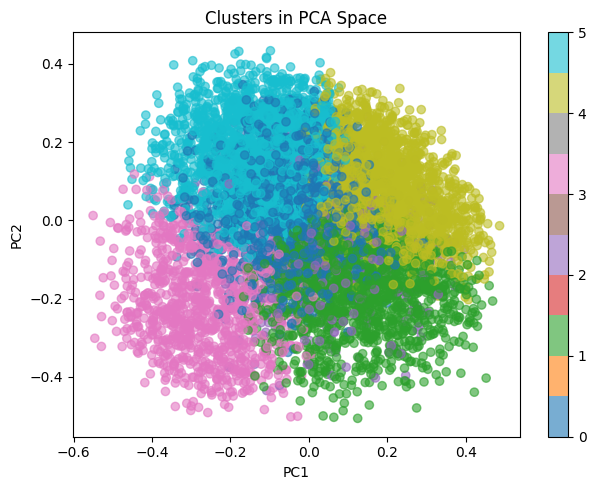

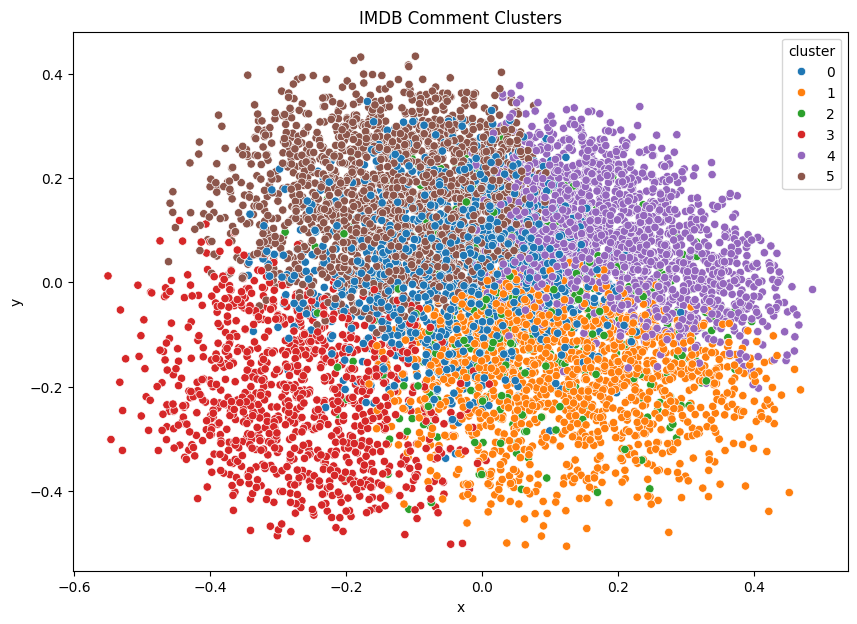

In [103]:
extract_keybert_keywords(df_en, model, num_keywords=10)

# Run comprehensive analysis
analyze_clusters_comprehensive(df_en, text_column='clean_comment')

# Extract unique n-grams
extract_unique_ngrams(df_en, text_column='processed_comment')

# Analyze themes
analyze_cluster_themes(df_en, text_column='processed_comment')

extract_all_keywords(df_en, num_clusters, model)

#get random reviews
get_sample_reviews(df_en, n_samples=3)

# If you have embeddings available
visualize_clusters(df_en, embeddings)
visualize_clusters2(df_en, embeddings)

In [104]:
def print_cluster_table(df):
    # Build the pivot table
    table = df[['title', 'cluster']].value_counts().unstack(fill_value=0)
  
    # Convert floats to ints if needed
    table = table.astype(int)

    # Print each row cleanly
    print("Title".ljust(40), end="")
    for col in table.columns:
        print(f"Cluster {col}".rjust(12), end="")
    print()

    print("-" * (40 + 12 * len(table.columns)))
    
    for title, row in table.iterrows():
        print(title.ljust(40), end="")
        for count in row:
            print(str(count).rjust(12), end="")
        print()

In [105]:
print_cluster_table(df_en)

Title                                      Cluster 0   Cluster 1   Cluster 2   Cluster 3   Cluster 4   Cluster 5
----------------------------------------------------------------------------------------------------------------
12 Angry Men                                       5           8           0           2           4           6
2001: A Space Odyssey                             10          38           1          38          49          64
A Beautiful Mind                                  45          11           1           4          31           3
Avatar                                             6          41           4          21          51          76
Black Swan                                        38          26           0          12          49          23
Bohemian Rhapsody                                 84          10           1          48          12          20
Catch Me If You Can                               14           8           2           7        

In [106]:
df_en

,title,comment,rating,processed_comment,clean_comment,cluster,review_length,x,y
0,Se7en,"So when this movie came out, it was pretty gor...",1,movie came pretty gory disgusting however toda...,came pretty gory disgusting however today soci...,0,51,0.060220,-0.076450
1,Se7en,Horrible movie. Incredibly boring and predicta...,1,horrible movie incredibly boring predictable t...,horrible incredibly boring predictable longing...,5,48,-0.121541,0.082868
2,Se7en,What a boring movie. Idk what the stupid hype ...,1,boring movie idk stupid hype,boring idk stupid hype,3,4,-0.427702,-0.075932
3,Se7en,"Well Kevin ruined the movie, obviously. I'd lo...",1,well kevin ruined movie obviously love see red...,well kevin ruined obviously love see redone ab...,0,17,-0.236877,0.061915
4,Se7en,Watched this because it was suggested in a rev...,1,watched suggested review much better picture m...,watched suggested review much better picture s...,5,59,-0.038046,0.309179
...,...,...,...,...,...,...,...,...,...
7702,Django Unchained,Just for a moment imagine this movie being mad...,4,moment imagine movie made unknown director wou...,moment imagine made unknown director would sav...,4,89,0.339542,0.147571
7703,Django Unchained,Last week I managed to watch Django Unchained ...,4,last week managed watch <MOVIE_TITLE> say litt...,last week managed say little disappointed scre...,5,46,-0.157416,0.339880
7704,Django Unchained,Another disappointment from Tarantino. A juven...,4,another disappointment <DIRECTOR_NAME> juvenil...,another disappointment <director_name> juvenil...,5,57,-0.001083,0.179759
7705,Django Unchained,One thing that you can always guarantee with a...,4,one thing always guarantee tarantino film hype...,thing always guarantee tarantino hype often fi...,4,226,0.435464,-0.000054
